<a href="https://colab.research.google.com/github/KirillYd/stamp_recognition/blob/text_recognition/CRNN_text_recognition.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import os
import math
import string

import cv2
import numpy as np
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

import tensorflow as tf
print(tf.__version__)
import tensorflow.keras.backend as K
from tensorflow.keras.backend import get_value, ctc_decode
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import *
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Nadam

from google.colab import drive

drive.mount('/content/drive')

2.17.0
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Data generator

In [3]:
import os

import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw, ImageFont

import torch
from torch.utils.data import Dataset, DataLoader

def generate_text(alphabet, seq_len=(2, 20)):
    seq_len = np.random.randint(seq_len[0], seq_len[1]+1)
    text = ''.join([np.random.choice(list(set(alphabet+alphabet.upper()))) for _ in range(seq_len)])

    while len(text.strip()) == 0:
        text = ''.join([np.random.choice(list(set(alphabet+alphabet.upper()))) for _ in range(seq_len)])

    r = np.random.rand()
    if r < 0.2:
        text = text.upper()
    elif r < 0.5:
        text = text.capitalize()
    else:
        text = text.lower()

    return text.strip()

def get_text_dimensions(text_string, font):
    ascent, descent = font.getmetrics()

    text_width = font.getmask(text_string).getbbox()[2]
    text_height = font.getmask(text_string).getbbox()[3] + descent

    return (text_width, text_height)

def safe_convert_to_grayscale(image_to_convert):
    if len(image_to_convert.shape) == 2:
        return image_to_convert
    if len(image_to_convert.shape) == 3:
        if image_to_convert.shape[2] == 1:
            return image_to_convert[:, :, 0]
        if image_to_convert.shape[2] == 3:
            return cv2.cvtColor(image_to_convert, cv2.COLOR_BGR2GRAY)
        if image_to_convert.shape[2] == 4:
            return cv2.cvtColor(image_to_convert, cv2.COLOR_BGRA2GRAY)

    raise ValueError('invalid shape')


def draw_underlined_text(draw, pos, text, font, **options):
    twidth, theight = get_text_dimensions(text, font)
    lx, ly = pos[0], pos[1] + theight

    width = theight // 5

    draw.text(pos, text, font=font, **options)
    draw.line((lx, ly, lx + twidth, ly), width=width, **options)

def draw_overlined_text(draw, pos, text, font, **options):
    twidth, theight = get_text_dimensions(text, font)
    lx, ly = pos[0], pos[1]

    width = theight // 10

    draw.text(pos, text, font=font, **options)
    draw.line((lx, ly, lx + twidth, ly), width=width, **options)


def rotate_image(image, angle):
    if angle == 0:
        return image
    image_center = tuple(np.array(image.shape[1::-1]) / 2)
    rot_mat = cv2.getRotationMatrix2D(image_center, angle, 1.0)

    delta_x = np.ceil(abs(rot_mat[0, 2])).astype(int)
    delta_y = np.ceil(abs(rot_mat[1, 2])).astype(int)

    image = cv2.copyMakeBorder(image, delta_y*2, delta_y*2, delta_x*2, delta_x*2, cv2.BORDER_CONSTANT, value=255)

    result = cv2.warpAffine(image, rot_mat, image.shape[1::-1], flags=cv2.INTER_LINEAR)
    result = result[delta_y: -delta_y, delta_x: -delta_x]
    return result


def add_salt_pepper_noise(image, salt_color, pepper_color, salt_p=0.025, pepper_p=0.025):
    salt_mask = np.random.rand(*image.shape[:2])
    salt_mask[salt_mask < 1-salt_p] = 0
    salt_mask[salt_mask > 0] = 1

    pepper_mask = np.random.rand(*image.shape[:2])
    pepper_mask[pepper_mask < 1-pepper_p] = 0
    pepper_mask[pepper_mask > 0] = 1

    image[salt_mask.astype(bool)] = salt_color
    image[pepper_mask.astype(bool)] = pepper_color

    return image


def prepare_segment_for_recognition(segment, target_shape=(32, 256), pad_value=255):
    segment = safe_convert_to_grayscale(segment)

    coef = min(target_shape[0] / segment.shape[0], target_shape[1] / segment.shape[1])

    segment = cv2.resize(segment, dsize=None, fx=coef, fy=coef, interpolation=cv2.INTER_AREA if coef < 1 else cv2.INTER_CUBIC)
    left = target_shape[1]-segment.shape[1]
    top = target_shape[0]-segment.shape[0]
    segment = cv2.copyMakeBorder(segment, 0, top, 0, left, cv2.BORDER_CONSTANT, value=(pad_value, pad_value, pad_value))

    return segment


def generate_sample(output_shape, alphabet, seq_len, bgs, fonts_path, pad_value):
    font_size = np.random.randint(12, 29)

    font = ImageFont.truetype(os.path.join(fonts_path, np.random.choice(os.listdir(fonts_path))), size=font_size)

    text = generate_text(alphabet, seq_len=seq_len)
    spaces_before = ' '*np.random.randint(0, 3)
    spaces_after = ' '*np.random.randint(0, 3)
    spaced_text = spaces_before + text + spaces_after
    text_w, text_h = get_text_dimensions(spaced_text, font)

    bg = np.full((text_h, text_w), dtype='uint8', fill_value=255)
    bg = Image.fromarray(bg)

    draw = ImageDraw.Draw(bg)

    fill = np.random.randint(0, 31)
    pos = (0, 0)

    r = np.random.random()
    if r < 0.1:
        draw_underlined_text(draw, pos, spaced_text, font, fill=fill)
    elif r < 0.2:
        draw_overlined_text(draw, pos, spaced_text, font, fill=fill)
    else:
        draw.text(pos, spaced_text, fill, font)

    img = np.array(bg)
    img = rotate_image(img, np.random.randint(-2, 3))

    if np.random.random() < 0.1 and img.shape[1] > font_size*2:
        img = img[:, font_size//4: -font_size//4]

    img = img[1:]

    if np.random.random() < 0.5:
        bg = np.full(img.shape[:2], dtype='uint8', fill_value=np.random.randint(230, 256))
    else:
        bg = bgs[np.random.randint(0, len(bgs))]
        if bg.shape[1] > img.shape[1] and bg.shape[0]> img.shape[0]:
            bg_x = np.random.randint(0, bg.shape[1]-img.shape[1]+1)
            bg_y = np.random.randint(0, bg.shape[0]-img.shape[0]+1)
            bg = bg[bg_y: bg_y+img.shape[0], bg_x: bg_x+img.shape[1]]
        else:
            bg = np.full_like(img, fill_value=np.random.randint(230, 256))

    img = np.minimum(img, bg)

    img = add_salt_pepper_noise(img, np.unique(bg)[0], fill)

    img = prepare_segment_for_recognition(img, output_shape, pad_value)

    return img, text.upper()

In [4]:
class OCRDataset(Dataset):
    def __init__(self, alphabet, output_shape, batch_size, num_steps, fonts_path='/content/drive/MyDrive/text_recognition/Data_gen/fonts', bgs_path='/content/drive/MyDrive/text_recognition/Data_gen/backgrounds'):
        super(Dataset, self).__init__()

        self.alphabet = alphabet
        self.batch_size = batch_size
        self.num_steps = num_steps
        self.output_shape = output_shape
        self.pad_value = 255
        self.fonts_path = fonts_path
        self.bgs = [cv2.imread(f'{bgs_path}/{fn}', cv2.IMREAD_GRAYSCALE) for fn in os.listdir(bgs_path)]

    def encode_text(self, text, seq_len, blank_idx=0):
        def _label_to_num(label):
            label_num = []
            for ch in label:
                idx = self.alphabet.find(ch)
                label_num.append(idx + (idx >= blank_idx))
            return np.array(label_num)

        if blank_idx < 0:
            blank_idx = len(self.alphabet)
        nums = np.full((seq_len,), fill_value=blank_idx, dtype='int32')
        nums[:len(text)] = _label_to_num(text)

        return nums

    def decode_target(self, nums, blank_idx=0):
        if blank_idx < 0:
            blank_idx = len(alphabet)
        nums_collapsed = [self.alphabet[idx-(idx >= blank_idx)] for idx in nums.cpu().detach().numpy() if idx != blank_idx]
        return ''.join(nums_collapsed)

    def decode_pred(self, logits, alphabet_idx, blank_idx=0):
        if blank_idx < 0:
            blank_idx = len(alphabet)
        nums = torch.argmax(logits, dim=-1)
        nums_collapsed = [self.alphabet[idx-(idx >= blank_idx)] for idx, _ in groupby(nums.cpu().detach().numpy()) if idx != blank_idx and idx < len(alphabet)]
        return ''.join(nums_collapsed)

    def __len__(self):
        return self.batch_size * self.num_steps

    def __getitem__(self, idx):
        image, text = generate_sample(output_shape=self.output_shape, alphabet=self.alphabet,
                                      seq_len=(3, 25), bgs=self.bgs, fonts_path=self.fonts_path, pad_value=self.pad_value)

        #image = torch.FloatTensor(image / 255).unsqueeze(0)
        #target = torch.IntTensor(self.encode_text(text, 32))

        return image, text

In [5]:
def collate_fn(batch):
    images, texts = zip(*batch)  # Распаковываем батч
    return list(images), list(texts)

from torch.utils.data import DataLoader, Dataset, random_split
alphabet = 'ЁАБВГДЕЖЗИЙКЛМНОПРСТУФХЦЧШЩЬЫЪЭЮЯ 0123456789!@№%?()-=+.,/«»:;~"<>[]'
batch_size = 64
num_steps = 100
output_shape=(32, 256)

dataset = OCRDataset(alphabet, output_shape, batch_size, num_steps)

#train_size = int(0.8 * len(dataset))
#valid_size = len(dataset) - train_size

#train_dataset, valid_dataset = random_split(dataset, [train_size, valid_size])

loader = DataLoader(dataset, batch_size=batch_size, shuffle=True, collate_fn=collate_fn, num_workers= 2)
 # num_workers - количество потоков CPU

In [77]:
#for image, text in loader:
  #for i in range(len(image)):
    #array_2d = image[i]
    #array_3d = array_2d.reshape((2, 2, 3))
    #plt.imshow()
    #plt.show()
    #image_color = cv2.cvtColor(image[i], cv2.COLOR_GRAY2RGB) # изменение 2х мерно в 3х мерный массив
    #print(image_color.shape)
   # break
  #break

(32, 256, 3)


Э


TypeError: Invalid shape (256,) for image data

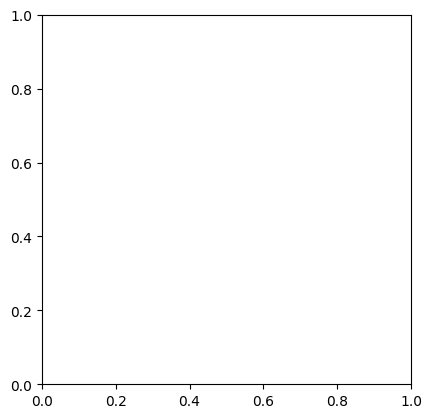

In [63]:
#test_X, test_y =
for image,text in loader:
  for i in range(len(image)):
    print(text[i])
    plt.imshow(image[i])
    plt.show()
    #cv2.imshow('Image', image[i])
    #cv2.imshow(image[i])
    #print(image[i])
    #plt.imshow(image[i])
    #plt.show()

#64*100

# Prepare dataset

In [2]:
!mkdir lines
# https://fki.tic.heia-fr.ch/DBs/iamDB/data/lines.tgz
!tar -xf path/to/lines.tgz -C ./lines
# https://fki.tic.heia-fr.ch/DBs/iamDB/data/ascii.tgz
!tar -xf path/to/ascii.tar -C ./

tar: path/to/lines.tgz: Cannot open: No such file or directory
tar: Error is not recoverable: exiting now
tar: path/to/ascii.tar: Cannot open: No such file or directory
tar: Error is not recoverable: exiting now


In [3]:
# Load labels

gt = pd.DataFrame(columns=['fn', 'value'])

with open('./lines.txt', 'r') as f:
  for index, row in enumerate(f):
    if row[0] == '#':
      continue
    row = row.split()
    gt.loc[gt.shape[0]] = (row[0], row[-1].replace('|', ' '))
gt.head(5)

FileNotFoundError: [Errno 2] No such file or directory: './lines.txt'

In [6]:
# Data preprocessing

def preprocess(img):
  for func in [resize_n_rotate, add_adaptiveThreshold]:
    img = func(img)
  return img


def resize_n_rotate(img, shape_to=(64, 800)): #shepe_to 64, 800
  if img.shape[0] > shape_to[0] or img.shape[1] > shape_to[1]:
    shrink_multiplayer = min(math.floor(shape_to[0] / img.shape[0] * 100) / 100,
                             math.floor(shape_to[1] / img.shape[1] * 100) / 100)
    img = cv2.resize(img, None,
                     fx=shrink_multiplayer,
                     fy=shrink_multiplayer,
                     interpolation=cv2.INTER_AREA)

  img = cv2.copyMakeBorder(img, math.ceil(shape_to[0]/2) - math.ceil(img.shape[0]/2),
                           math.floor(shape_to[0]/2) - math.floor(img.shape[0]/2),
                           math.ceil(shape_to[1]/2) - math.ceil(img.shape[1]/2),
                           math.floor(shape_to[1]/2) - math.floor(img.shape[1]/2),
                           cv2.BORDER_CONSTANT, value=255)
  return cv2.rotate(img, cv2.ROTATE_90_CLOCKWISE)


def add_adaptiveThreshold(img):
  return cv2.adaptiveThreshold(img, 255, cv2.ADAPTIVE_THRESH_MEAN_C, cv2.THRESH_BINARY_INV, 21, 10).astype('bool')


# Label encoding

def encode_text(texts):
  def _label_to_num(label, alphabet):
    label_num = []
    for ch in label:
      label_num.append(alphabet.find(ch))
    return np.array(label_num)

  alphabet = ''.join(sorted(pd.Series(texts).apply(list).apply(pd.Series).stack().unique()))

  nums = np.ones([len(texts), max([len(text) for text in texts])], dtype='int64') * len(alphabet)
  for i, text in enumerate(texts):
    nums[i][:len(text)] = _label_to_num(text, alphabet)

  return nums, alphabet

In [7]:
#image = np.random.rand(32, 256, 3) * 255  # Случайное цветное изображение
#img = cv2.imread("/content/drive/MyDrive/text_recognition/111.jpg", 0)
#print(img.shape)
#plt.imshow(img)
#plt.show()
#print(type(img))
#image = image.astype(np.uint8)
#print(image)
train_X, train_y = [], []
for image,text in loader:
  for i in range(len(image)):
    train_X.append(preprocess(image[i]))
    train_y.append(text[i])

train_X = np.array(train_X)
train_y, alphabet = encode_text(train_y)
alphabet
  #print(train_X, train_y)

    #print(text[i])
    #plt.imshow(image[i])
    #plt.show()

' !"%()+,-./0123456789:;<=>?@[]~«»ЁАБВГДЕЖЗИЙКЛМНОПРСТУФХЦЧШЩЪЫЬЭЮЯ№'

In [8]:
train_X, val_X, train_y, val_y  = train_test_split(train_X, train_y, test_size=0.2, random_state=42)
train_X, test_X, train_y, test_y  = train_test_split(train_X, train_y, test_size=0.25, random_state=42)

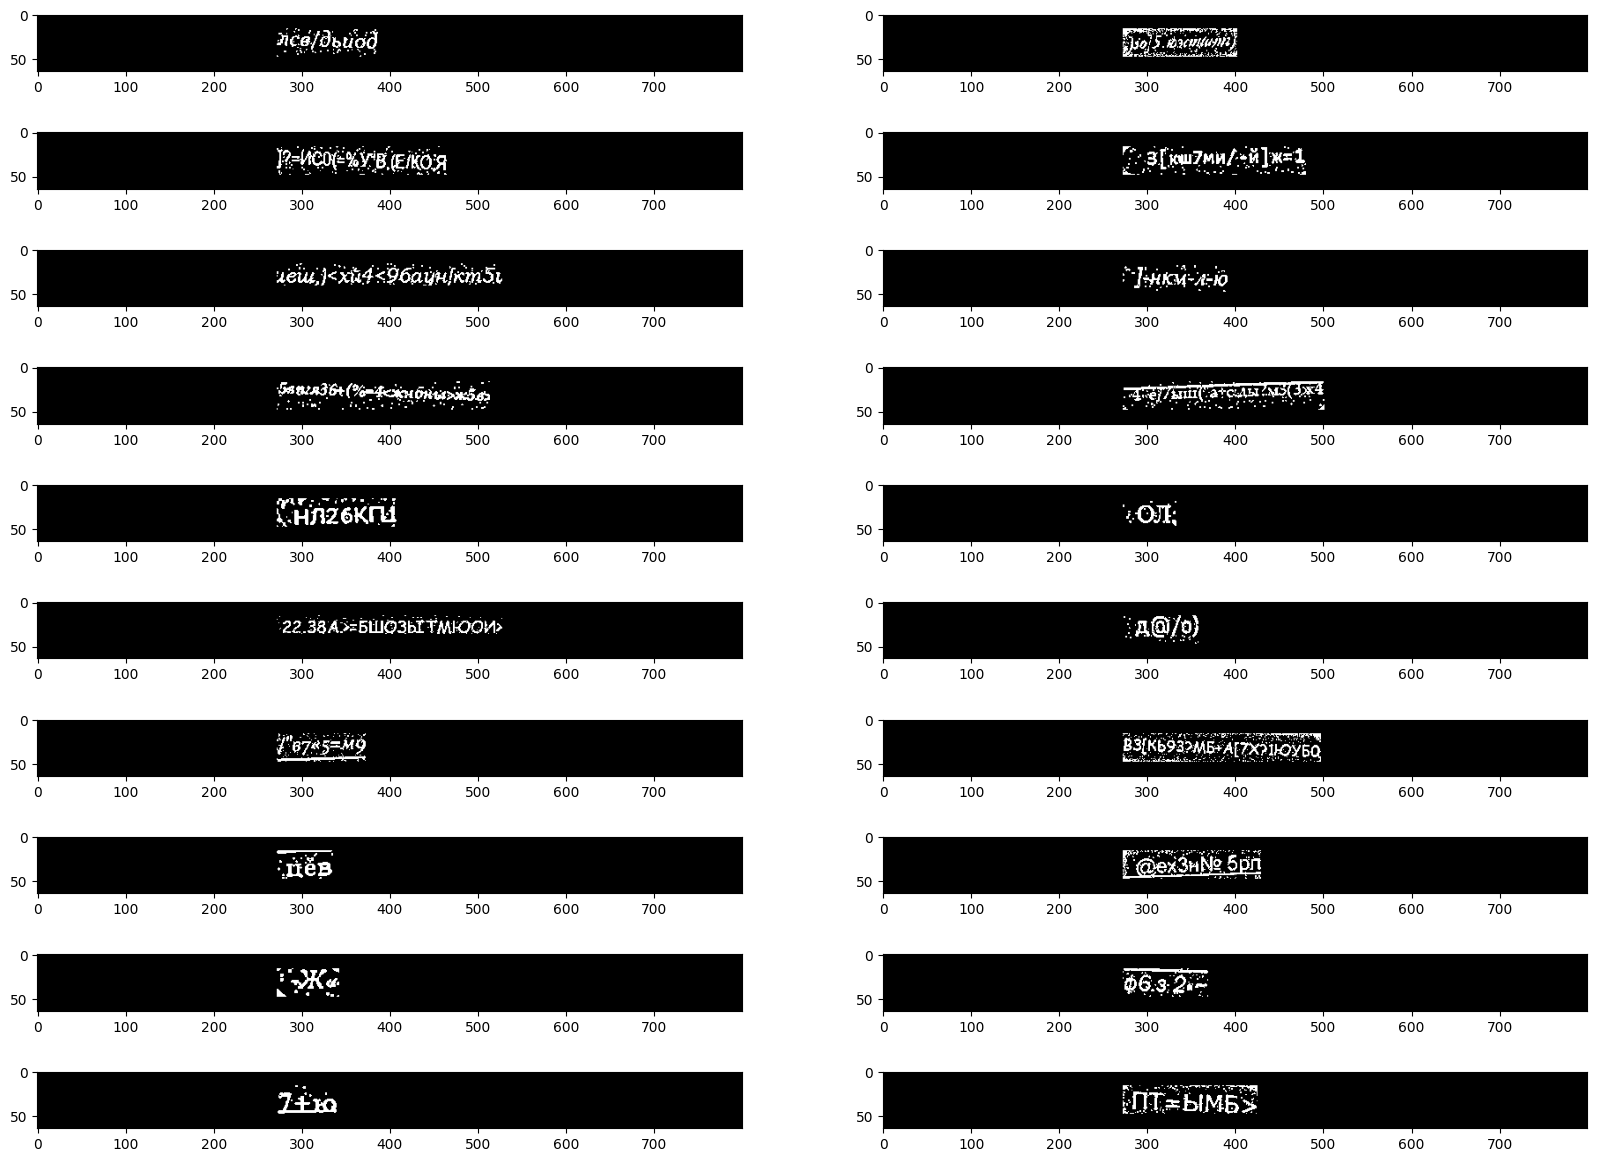

In [9]:
fig, axes = plt.subplots(figsize=(20, 15), ncols=2, nrows=10)

# Preprocess example

for i in range(10):
  for j in range(2):
    axes[i, j % 2].imshow(cv2.rotate(
        (train_X[i * 2 + j % 2]).astype(np.uint8),cv2.ROTATE_90_COUNTERCLOCKWISE),
        cmap='gray')

# Model

In [15]:
class CERMetric(tf.keras.metrics.Metric):
    """
    A custom Keras metric to compute the Character Error Rate
    """
    def __init__(self, name='CER_metric', **kwargs):
        super(CERMetric, self).__init__(name=name, **kwargs)
        self.cer_accumulator = self.add_weight(name="total_cer", initializer="zeros")
        self.counter = self.add_weight(name="cer_count", initializer="zeros")

    def update_state(self, y_true, y_pred, sample_weight=None):
        input_shape = K.shape(y_pred)
        input_length = tf.ones(shape=input_shape[0]) * K.cast(input_shape[1], 'float32')

        decode, log = K.ctc_decode(y_pred, input_length, greedy=True)

        decode = K.ctc_label_dense_to_sparse(decode[0], K.cast(input_length, 'int32'))
        y_true_sparse = K.ctc_label_dense_to_sparse(y_true, K.cast(input_length, 'int32'))
        y_true_sparse = tf.sparse.retain(y_true_sparse, tf.not_equal(y_true_sparse.values, tf.math.reduce_max(y_true_sparse.values)))

        decode = tf.sparse.retain(decode, tf.not_equal(decode.values, -1))
        distance = tf.edit_distance(decode, y_true_sparse, normalize=True)

        self.cer_accumulator.assign_add(tf.reduce_sum(distance))
        self.counter.assign_add(K.cast(tf.shape(y_true)[0], 'float32'))

    def result(self):
        return tf.math.divide_no_nan(self.cer_accumulator, self.counter)

    def reset_state(self):
        self.cer_accumulator.assign(0.0)
        self.counter.assign(0.0)


def CTCLoss(y_true, y_pred):
    """
    Compute the training-time loss value
    """
    batch_len = tf.cast(tf.shape(y_true)[0], dtype="int64")
    input_length = tf.cast(tf.shape(y_pred)[1], dtype="int64")
    label_length = tf.cast(tf.shape(y_true)[1], dtype="int64")

    input_length = input_length * tf.ones(shape=(batch_len, 1), dtype="int64")
    label_length = label_length * tf.ones(shape=(batch_len, 1), dtype="int64")

    loss = K.ctc_batch_cost(y_true, y_pred, input_length, label_length)
    return loss

In [16]:
model = Sequential()

model.add(Conv2D(64, (5, 5), padding='same', activation=LeakyReLU(alpha=0.01), input_shape=(800, 64, 1)))
model.add(MaxPooling2D((2, 2)))

model.add(Conv2D(128, (5, 5), padding='same', activation=LeakyReLU(alpha=0.01)))
model.add(MaxPooling2D((1, 2)))

model.add(Conv2D(128, (3, 3), padding='same', activation=LeakyReLU(alpha=0.01)))
model.add(MaxPooling2D((2, 2)))
model.add(BatchNormalization())

model.add(Conv2D(256, (3, 3), padding='same', activation=LeakyReLU(alpha=0.01)))

model.add(Conv2D(256, (3, 3), padding='same', activation=LeakyReLU(alpha=0.01)))
model.add(MaxPooling2D((2, 2)))

model.add(Conv2D(512, (3, 3), padding='same', activation=LeakyReLU(alpha=0.01)))
model.add(MaxPooling2D((1, 2)))
model.add(BatchNormalization())

model.add(Conv2D(512, (3, 3), padding='same', activation=LeakyReLU(alpha=0.01)))
model.add(MaxPooling2D((1, 2)))

model.add(Reshape((100, 512)))

model.add(Bidirectional(LSTM(256, return_sequences=True)))
model.add(Bidirectional(LSTM(256, return_sequences=True)))

model.add(Dense(len(alphabet) + 1, activation='softmax')) # +1 for ctc blank

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_7 (Conv2D)                    │ (None, 800, 64, 64)         │           1,664 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_6 (MaxPooling2D)       │ (None, 400, 32, 64)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_8 (Conv2D)                    │ (None, 400, 32, 128)        │         204,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_7 (MaxPooling2D)       │ (None, 400, 16, 128)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_9 (Conv2D)                    │ (None, 400, 16, 128)        │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_8 (MaxPooling2D)       │ (None, 200, 8, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 200, 8, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_10 (Conv2D)                   │ (None, 200, 8, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_11 (Conv2D)                   │ (None, 200, 8, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_9 (MaxPooling2D)       │ (None, 100, 4, 256)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_12 (Conv2D)                   │ (None, 100, 4, 512)         │       1,180,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_10 (MaxPooling2D)      │ (None, 100, 2, 512)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 100, 2, 512)         │           2,048 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_13 (Conv2D)                   │ (None, 100, 2, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_11 (MaxPooling2D)      │ (None, 100, 1, 512)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ reshape_1 (Reshape)                  │ (None, 100, 512)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional_2 (Bidirectional)      │ (None, 100, 512)            │       1,574,912 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional_3 (Bidirectional)      │ (None, 100, 512)            │       1,574,912 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 100, 68)             │          34,884 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 7,966,660 (30.39 MB)

 Trainable params: 7,965,380 (30.39 MB)

 Non-trainable params: 1,280 (5.00 KB)

In [17]:
model.compile(optimizer=Nadam(learning_rate=0.001, clipnorm=1.0), loss=CTCLoss, metrics=[CERMetric()])

# Train model

In [19]:
history = model.fit(train_X, train_y, validation_data=(val_X, val_y),
                    epochs=75, batch_size=64,
                    callbacks=[EarlyStopping(patience=10, restore_best_weights=True, monitor='val_CER_metric', mode='min'),
                              ReduceLROnPlateau(factor=0.5, min_lr=1e-5, patience=4, monitor='val_CER_metric')],
                    verbose=1)

Epoch 1/75
60/60 ━━━━━━━━━━━━━━━━━━━━ 36s 605ms/step - CER_metric: 1.0000 - loss: 61.9208 - val_CER_metric: 1.0000 - val_loss: 102.3506 - learning_rate: 0.0010
Epoch 2/75
60/60 ━━━━━━━━━━━━━━━━━━━━ 39s 581ms/step - CER_metric: 1.0000 - loss: 61.3675 - val_CER_metric: 1.0000 - val_loss: 101.6271 - learning_rate: 0.0010
Epoch 3/75
60/60 ━━━━━━━━━━━━━━━━━━━━ 41s 687ms/step - CER_metric: 1.0000 - loss: 60.4269 - val_CER_metric: 1.0000 - val_loss: 97.1151 - learning_rate: 0.0010
Epoch 4/75
60/60 ━━━━━━━━━━━━━━━━━━━━ 77s 597ms/step - CER_metric: 0.9956 - loss: 57.6803 - val_CER_metric: 1.0000 - val_loss: 98.0590 - learning_rate: 0.0010
Epoch 5/75
60/60 ━━━━━━━━━━━━━━━━━━━━ 41s 599ms/step - CER_metric: 0.9279 - loss: 51.9123 - val_CER_metric: 1.0000 - val_loss: 108.9730 - learning_rate: 0.0010
Epoch 6/75
60/60 ━━━━━━━━━━━━━━━━━━━━ 35s 581ms/step - CER_metric: 0.8397 - loss: 44.3113 - val_CER_metric: 0.9902 - val_loss: 101.4814 - learning_rate: 5.0000e-04
Epoch 7/75
60/60 ━━━━━━━━━━━━━━━━━━━━ 

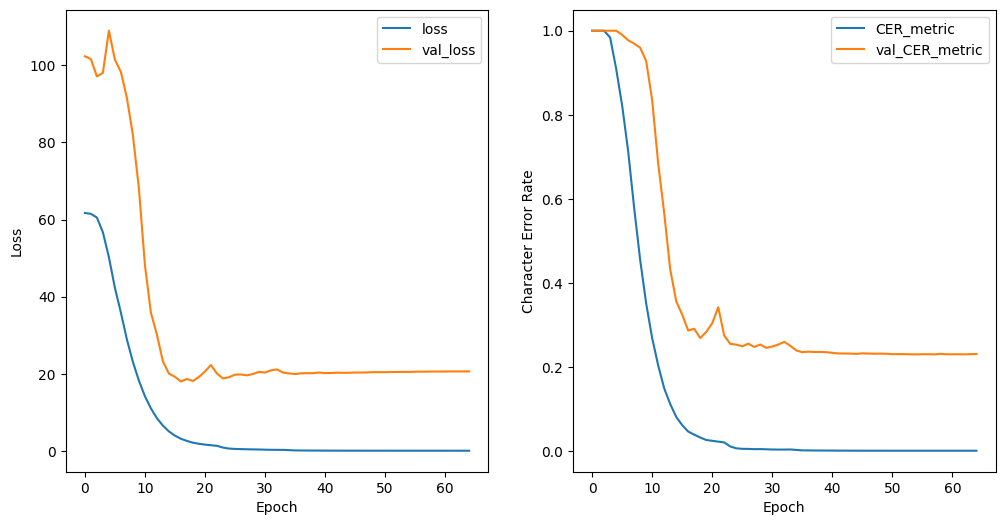

In [20]:
fig, axes = plt.subplots(figsize=(12, 6), ncols=2, nrows=1)

axes[0].plot(history.history['loss'], label='loss')
axes[0].plot(history.history['val_loss'], label='val_loss')
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[1].plot(history.history['CER_metric'], label='CER_metric')
axes[1].plot(history.history['val_CER_metric'], label='val_CER_metric')
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Character Error Rate")
axes[1].legend()

plt.show()

In [21]:
model.save('./crnn.h5')

In [22]:
model.save('/content/drive/MyDrive/text_recognition/Data_gen/model/crnn.h5')

In [23]:
model.save('/content/drive/MyDrive/text_recognition/Data_gen/model/crnn.keras')

In [ ]:
# model = load_model('path/to/model', custom_objects={'CTCLoss' : CTCLoss, 'CERMetric': CERMetric})

## Model training results

In [24]:
# Test results: (loss, cer)

model.evaluate(test_X, test_y)

40/40 ━━━━━━━━━━━━━━━━━━━━ 9s 134ms/step - CER_metric: 0.2244 - loss: 20.1419


[20.40312385559082, 0.22694405913352966]

In [25]:
# Decode label for single image

def num_to_label(num, alphabet):
    text = ""
    for ch in num:
        if ch == len(alphabet): # ctc blank
          break
        else:
          text += alphabet[ch]
    return text


# Decode labels for softmax matrix

def decode_text(nums):
  values = get_value(
      ctc_decode(nums, input_length=np.ones(nums.shape[0])*nums.shape[1],
                 greedy=True)[0][0])

  texts = []
  for i in range(nums.shape[0]):
    value = values[i]
    texts.append(num_to_label(value[value >= 0], alphabet))
  return texts

In [26]:
predicts = model.predict(test_X)
predicts = decode_text(predicts)

40/40 ━━━━━━━━━━━━━━━━━━━━ 4s 79ms/step


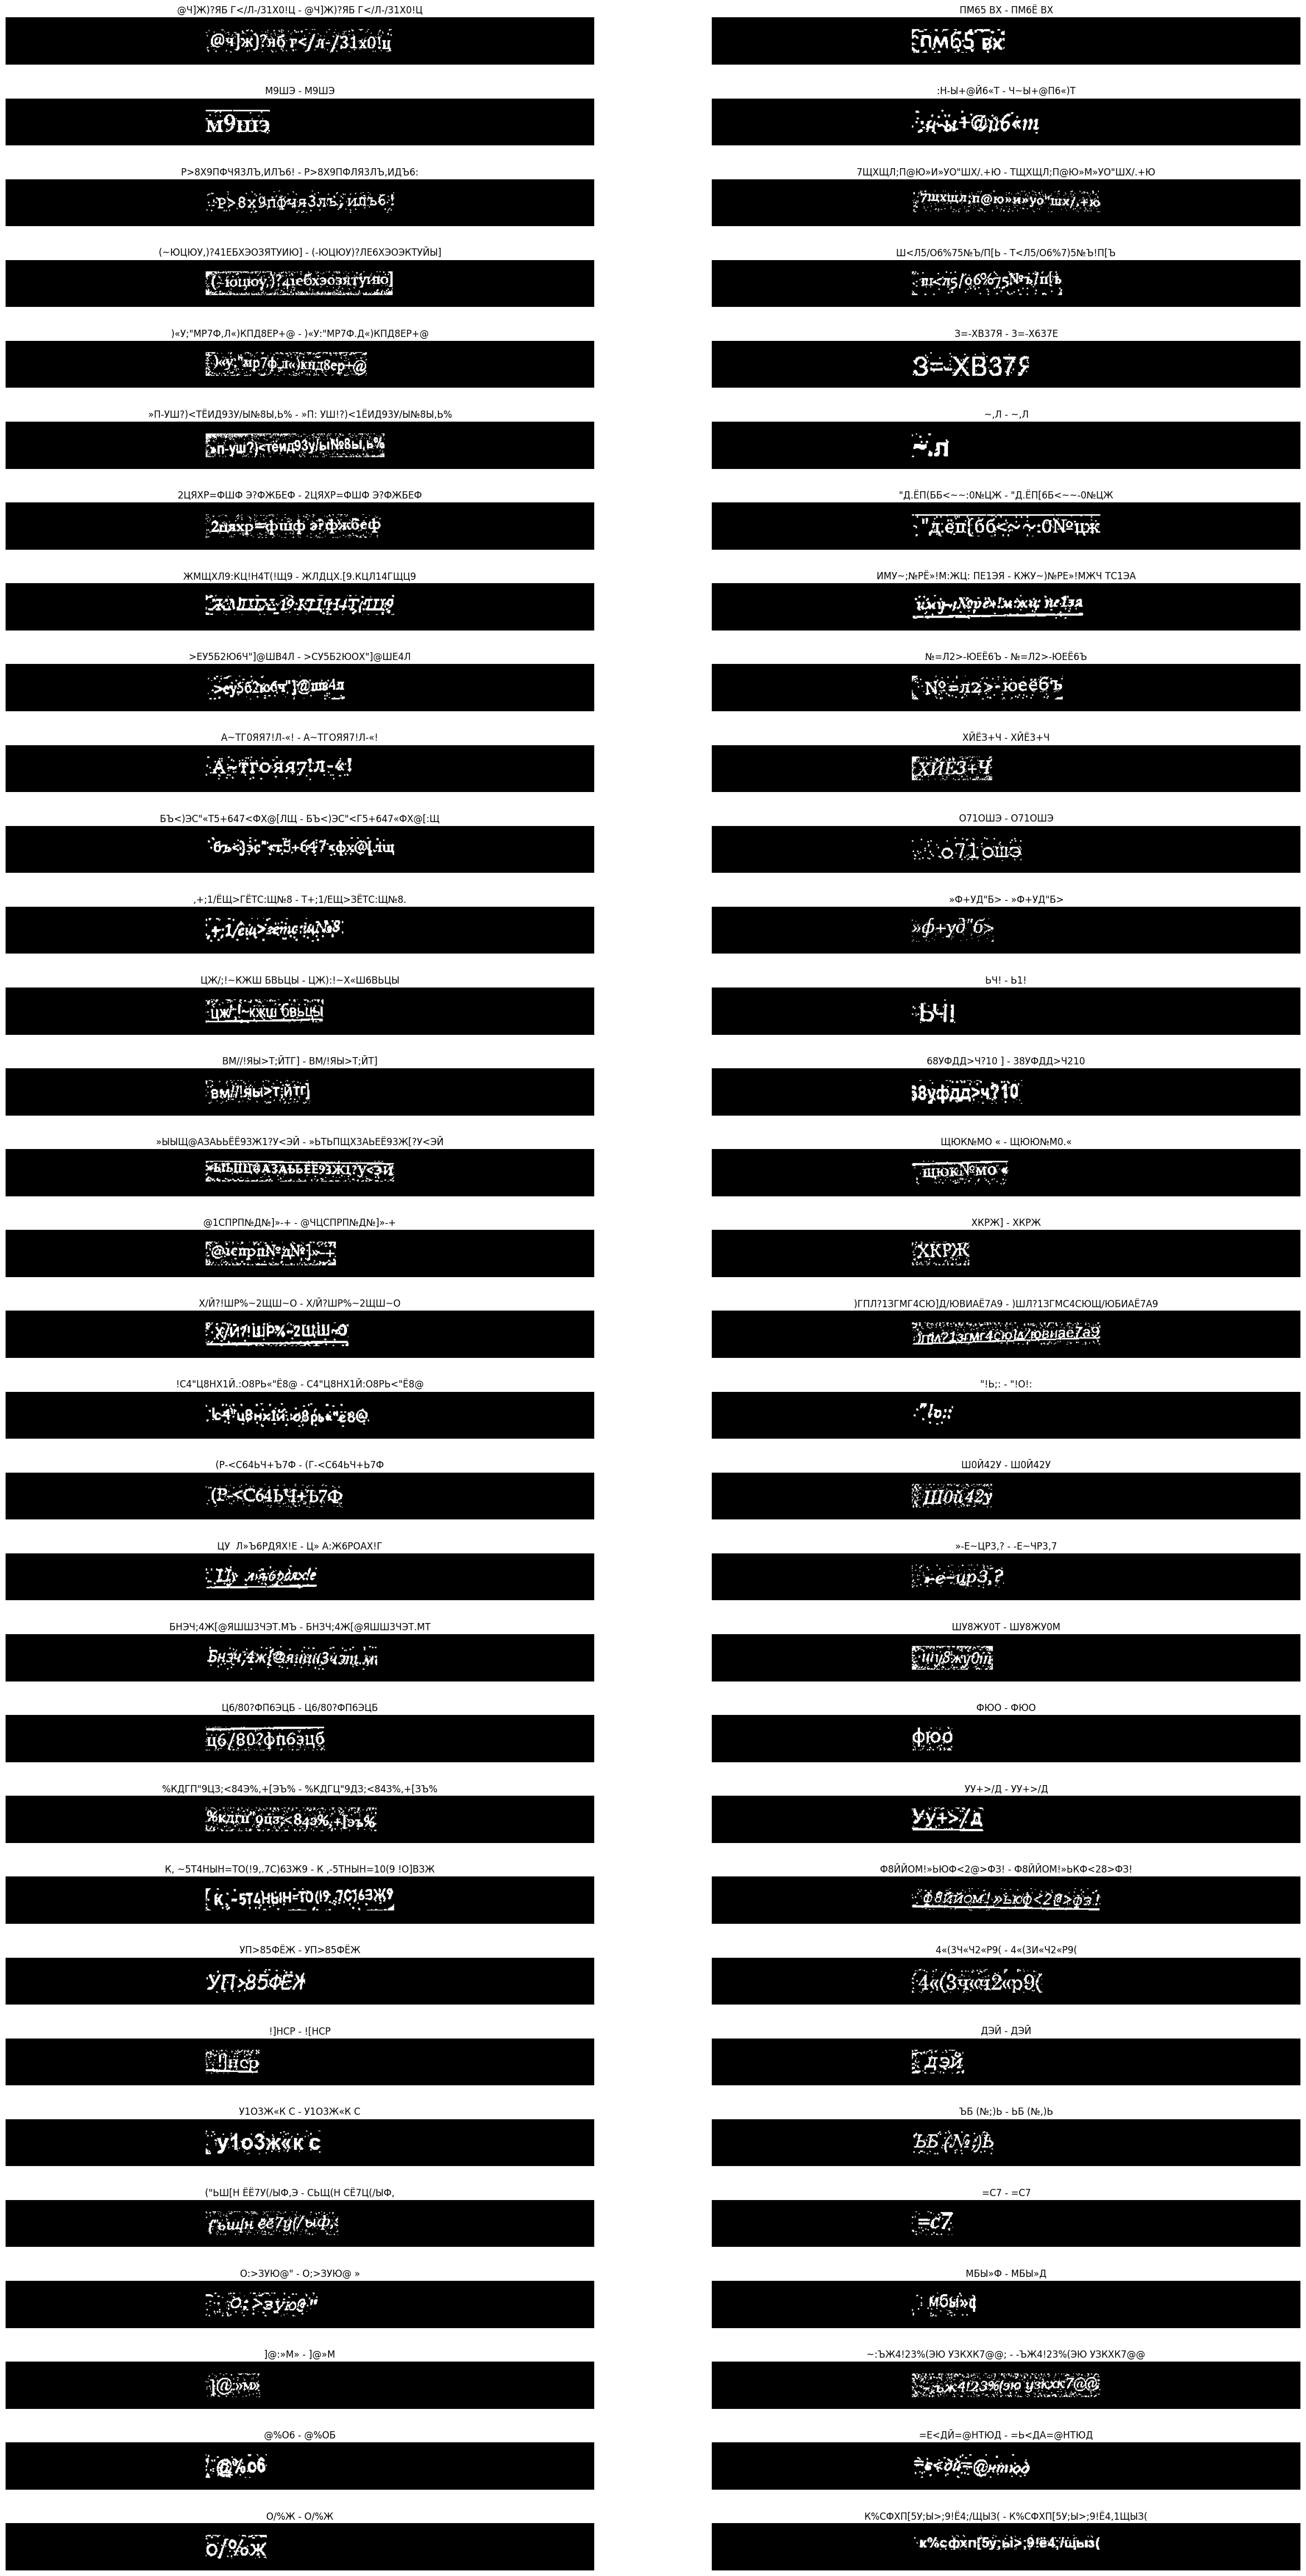

In [27]:
# Prediction results

fig, axes = plt.subplots(figsize=(30, 60), ncols=2, nrows=32)

test_X = test_X.astype('int')

# Title format: GT - Predict
for i in range(64):
  axes[i // 2, i % 2].imshow(cv2.rotate(
      (test_X[i]).astype(np.uint8),cv2.ROTATE_90_COUNTERCLOCKWISE),
      cmap='gray')
  axes[i // 2, i % 2].set_title(
      f'{num_to_label(test_y[i], alphabet)} - {predicts[i]}')
  axes[i // 2, i % 2].axis("off")

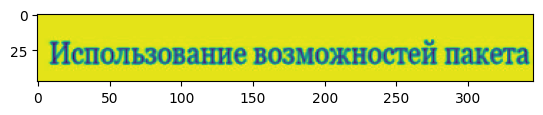

[[247 247 247 ... 247 247 247]
 [247 247 247 ... 247 247 247]
 [247 247 247 ... 247 247 247]
 ...
 [247 247 247 ... 247 247 247]
 [247 247 247 ... 247 247 247]
 [247 247 247 ... 247 247 247]]
[array([[False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       ...,
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False]])]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step


ValueError: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()

In [39]:
abc = []
img1 = cv2.imread("/content/drive/MyDrive/text_recognition/123.jpg", 0)
plt.imshow(img1)
plt.show()
print(img1)
abc.append(preprocess(img1))
print(abc)
abc = np.array(abc)
#print(abc)
pred_img = model.predict(abc)
preds = num_to_label(pred_img, alphabet)
#predicts = decode_text(pred_img)